# Regression Model

In [1]:
!pip install scikit-learn
!pip install joblib
!pip install faker

In [2]:
import pandas as pd
df = pd.read_csv("e_commerce_store.csv")

In [3]:
"""
Step-by-Step Machine Learning Regression Model for Profit Prediction
Educational Code - Execute Each Section Separately
"""

import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [4]:
import pandas as pd
import numpy as np
from faker import Faker

# Set random seed for reproducibility
np.random.seed(42)
fake = Faker()

print("="*70)
print("MACHINE LEARNING REGRESSION MODEL - STEP BY STEP TUTORIAL")
print("="*70)

# ============================================================================ 
# STEP 1: LOAD YOUR ORIGINAL DATASET
# ============================================================================ 
print("\n" + "="*70)
print("STEP 1: LOAD ORIGINAL DATASET (670 entries)")
print("="*70)

# Original dataset (670 rows)
data_original = {
    'Sales': np.random.normal(45000, 15000, 670),
    'Units Sold': np.random.normal(340, 100, 670),
    'Discount (%)': np.random.normal(15, 8, 670),
    'Customer Rating': np.random.normal(4.1, 0.8, 670),
}
df_original = pd.DataFrame(data_original)
df_original['Profit'] = df_original['Sales'] * 0.3 + np.random.normal(0, 1000, 670)

print(f"✓ Original dataset loaded successfully")
print(f"✓ Original dataset shape: {df_original.shape}")
print(f"\nFirst 5 rows:")
print(df_original.head())

print(f"\nBasic Statistics (Original):")
print(df_original.describe())

# ============================================================================ 
# STEP 2: EXPAND DATASET (SYNTHETIC DATA)
# ============================================================================ 
print("\n" + "="*70)
print("STEP 2: EXPAND DATASET WITH SYNTHETIC DATA (~5000 entries)")
print("="*70)

def generate_synthetic_data(n, df_ref):
    """Generate synthetic data based on reference dataframe statistics."""
    data = {
        'Sales': np.random.normal(df_ref['Sales'].mean(), df_ref['Sales'].std(), n),
        'Units Sold': np.random.normal(df_ref['Units Sold'].mean(), df_ref['Units Sold'].std(), n),
        'Discount (%)': np.random.normal(df_ref['Discount (%)'].mean(), df_ref['Discount (%)'].std(), n),
        'Customer Rating': np.random.normal(df_ref['Customer Rating'].mean(), df_ref['Customer Rating'].std(), n),
    }
    df_syn = pd.DataFrame(data)
    # Approximate Profit as correlated with Sales + noise
    df_syn['Profit'] = df_syn['Sales'] * 0.3 + np.random.normal(0, 1000, n)
    return df_syn

df_synthetic = generate_synthetic_data(5000, df_original)

# Concatenate original + synthetic
df_expanded = pd.concat([df_original, df_synthetic], ignore_index=True)

print(f"✓ Expanded dataset shape: {df_expanded.shape}")
print(f"\nFirst 5 rows of expanded dataset:")
print(df_expanded.head())

print(f"\nBasic Statistics (Expanded):")
print(df_expanded.describe())


MACHINE LEARNING REGRESSION MODEL - STEP BY STEP TUTORIAL

STEP 1: LOAD ORIGINAL DATASET (670 entries)
✓ Original dataset loaded successfully
✓ Original dataset shape: (670, 5)

First 5 rows:
          Sales  Units Sold  Discount (%)  Customer Rating        Profit
0  52450.712295  464.608519     16.284592         2.813952  16414.356464
1  42926.035482  132.660977     15.024368         3.489820  12575.765145
2  54715.328072  305.731241     18.495505         3.484686  16085.150635
3  67845.447846  302.855913     24.525170         3.348078  21085.505058
4  41487.699379  199.248831     22.596433         4.763580  12781.367843

Basic Statistics (Original):
               Sales  Units Sold  Discount (%)  Customer Rating        Profit
count     670.000000  670.000000    670.000000       670.000000    670.000000
mean    44891.558961  348.276755     15.438666         4.099761  13471.820027
std     14811.673387   97.836853      7.974325         0.781147   4628.123186
min     -3619.010101   50.37

In [5]:
df = df_expanded.copy()

In [6]:
# ============================================================================
# STEP 3: PREPARE FEATURES (X) AND TARGET (y)
# ============================================================================
print("\n" + "="*70)
print("STEP 3: PREPARE FEATURES AND TARGET VARIABLE")
print("="*70)

# Define features (independent variables)
feature_columns = ['Sales', 'Units Sold', 'Discount (%)', 'Customer Rating']
X = df[feature_columns].copy()

# Define target (dependent variable)
y = df['Profit'].copy()

print(f"Features (X):")
print(f"  Shape: {X.shape}")
print(f"  Columns: {list(X.columns)}")

print(f"\nTarget (y):")
print(f"  Shape: {y.shape}")
print(f"  Variable: Profit")






STEP 3: PREPARE FEATURES AND TARGET VARIABLE
Features (X):
  Shape: (5670, 4)
  Columns: ['Sales', 'Units Sold', 'Discount (%)', 'Customer Rating']

Target (y):
  Shape: (5670,)
  Variable: Profit


In [7]:
# ============================================================================ 
# STEP 4: SPLIT DATA INTO TRAIN, VALIDATION, AND TEST SETS
# ============================================================================ 
print("\n" + "="*70)
print("STEP 4: SPLIT DATA (80% Train, 10% Validation, 10% Test)")
print("="*70)

# First split: separate test set (10% of total)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)
print(f"✓ Test set separated: {len(X_test)} samples (~10%)")

# Second split: split remaining 90% into train (80/90 ≈ 88.89%) and val (10/90 ≈ 11.11%)
val_ratio = 0.1111  # 10% of total from remaining 90%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio, random_state=42
)

print(f"✓ Training set: {len(X_train)} samples (~80%)")
print(f"✓ Validation set: {len(X_val)} samples (~10%)")
print(f"✓ Test set: {len(X_test)} samples (~10%)")

print(f"\nTotal samples: {len(X_train) + len(X_val) + len(X_test)}")



STEP 4: SPLIT DATA (80% Train, 10% Validation, 10% Test)
✓ Test set separated: 567 samples (~10%)
✓ Training set: 4536 samples (~80%)
✓ Validation set: 567 samples (~10%)
✓ Test set: 567 samples (~10%)

Total samples: 5670


In [8]:
# ============================================================================
# STEP 5: STANDARDIZE FEATURES (SCALING)
# ============================================================================
print("\n" + "="*70)
print("STEP 5: STANDARDIZE FEATURES")
print("="*70)

print("Creating StandardScaler...")
scaler = StandardScaler()

print("Fitting scaler on training data...")
scaler.fit(X_train)
print("✓ Scaler fitted")

print("\nTransforming training set...")
X_train_scaled = scaler.transform(X_train)
print(f"✓ Training set scaled: {X_train_scaled.shape}")

print("Transforming validation set...")
X_val_scaled = scaler.transform(X_val)
print(f"✓ Validation set scaled: {X_val_scaled.shape}")

print("Transforming test set...")
X_test_scaled = scaler.transform(X_test)
print(f"✓ Test set scaled: {X_test_scaled.shape}")

print("\nScaling completed! All features now have mean=0 and std=1")




STEP 5: STANDARDIZE FEATURES
Creating StandardScaler...
Fitting scaler on training data...
✓ Scaler fitted

Transforming training set...
✓ Training set scaled: (4536, 4)
Transforming validation set...
✓ Validation set scaled: (567, 4)
Transforming test set...
✓ Test set scaled: (567, 4)

Scaling completed! All features now have mean=0 and std=1


In [9]:
# ============================================================================
# STEP 6: TRAIN MODEL WITH MULTIPLE EPOCHS AND CROSS-VALIDATION
# ============================================================================
print("\n" + "="*70)
print("STEP 6: TRAIN MODEL (10 EPOCHS WITH 3-FOLD CROSS-VALIDATION)")
print("="*70)

# Initialize model
model = LinearRegression()
print("✓ Linear Regression model initialized")

# Training parameters
n_epochs = 10
n_folds = 3

# Storage for metrics
train_rmse_list = []
val_rmse_list = []
epoch_cv_results = []

# Create KFold object for cross-validation
kfold = KFold(n_splits=n_folds, shuffle=True, random_state=42)

print(f"\nStarting training: {n_epochs} epochs with {n_folds}-fold cross-validation")
print(f"Sleep time between epochs: 5 seconds\n")

# Training loop
for epoch in range(1, n_epochs + 1):
    print("-" * 70)
    print(f"EPOCH {epoch}/{n_epochs}")
    print("-" * 70)
    
    # Store fold results for this epoch
    fold_train_scores = []
    fold_val_scores = []
    
    # Perform k-fold cross-validation
    for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train_scaled), 1):
        # Split data for this fold
        X_fold_train = X_train_scaled[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train_scaled[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        # Train model on this fold
        model.fit(X_fold_train, y_fold_train)
        
        # Predict
        y_fold_train_pred = model.predict(X_fold_train)
        y_fold_val_pred = model.predict(X_fold_val)
        
        # Calculate RMSE
        fold_train_rmse = np.sqrt(mean_squared_error(y_fold_train, y_fold_train_pred))
        fold_val_rmse = np.sqrt(mean_squared_error(y_fold_val, y_fold_val_pred))
        
        fold_train_scores.append(fold_train_rmse)
        fold_val_scores.append(fold_val_rmse)
        
        print(f"  Fold {fold_idx}/{n_folds} - Train RMSE: {fold_train_rmse:.2f}, Val RMSE: {fold_val_rmse:.2f}")
    
    # Calculate average RMSE across folds
    avg_train_rmse = np.mean(fold_train_scores)
    avg_val_rmse = np.mean(fold_val_scores)
    
    train_rmse_list.append(avg_train_rmse)
    val_rmse_list.append(avg_val_rmse)
    
    print(f"\n  EPOCH {epoch} AVERAGE:")
    print(f"    Train RMSE: {avg_train_rmse:.2f}")
    print(f"    Val RMSE: {avg_val_rmse:.2f}")
    
    # CALLBACK: Check for overfitting
    overfitting_threshold = 1.15  # Val RMSE > 1.15 * Train RMSE
    if avg_val_rmse > (avg_train_rmse * overfitting_threshold):
        print(f"\n  ⚠️  WARNING: POTENTIAL OVERFITTING DETECTED!")
        print(f"      Validation RMSE is {(avg_val_rmse/avg_train_rmse):.2f}x higher than Training RMSE")
        print(f"      Consider regularization or early stopping")
    else:
        print(f"\n  ✓ No overfitting detected (Val/Train ratio: {(avg_val_rmse/avg_train_rmse):.2f})")
    
    # Train final model on full training set for this epoch
    model.fit(X_train_scaled, y_train)
    
    # Sleep between epochs (as requested)
    if epoch < n_epochs:
        print(f"\n  Sleeping for 5 seconds before next epoch...")
        time.sleep(5)

print("\n" + "="*70)
print("✓ TRAINING COMPLETED!")
print("="*70)




STEP 6: TRAIN MODEL (10 EPOCHS WITH 3-FOLD CROSS-VALIDATION)
✓ Linear Regression model initialized

Starting training: 10 epochs with 3-fold cross-validation
Sleep time between epochs: 5 seconds

----------------------------------------------------------------------
EPOCH 1/10
----------------------------------------------------------------------
  Fold 1/3 - Train RMSE: 982.48, Val RMSE: 963.70
  Fold 2/3 - Train RMSE: 977.87, Val RMSE: 973.07
  Fold 3/3 - Train RMSE: 966.93, Val RMSE: 994.35

  EPOCH 1 AVERAGE:
    Train RMSE: 975.76
    Val RMSE: 977.04

  ✓ No overfitting detected (Val/Train ratio: 1.00)

  Sleeping for 5 seconds before next epoch...
----------------------------------------------------------------------
EPOCH 2/10
----------------------------------------------------------------------
  Fold 1/3 - Train RMSE: 982.48, Val RMSE: 963.70
  Fold 2/3 - Train RMSE: 977.87, Val RMSE: 973.07
  Fold 3/3 - Train RMSE: 966.93, Val RMSE: 994.35

  EPOCH 2 AVERAGE:
    Train RMS


STEP 7: VISUALIZE TRAINING PROGRESS
✓ Training progress plot saved as 'training_progress.png'


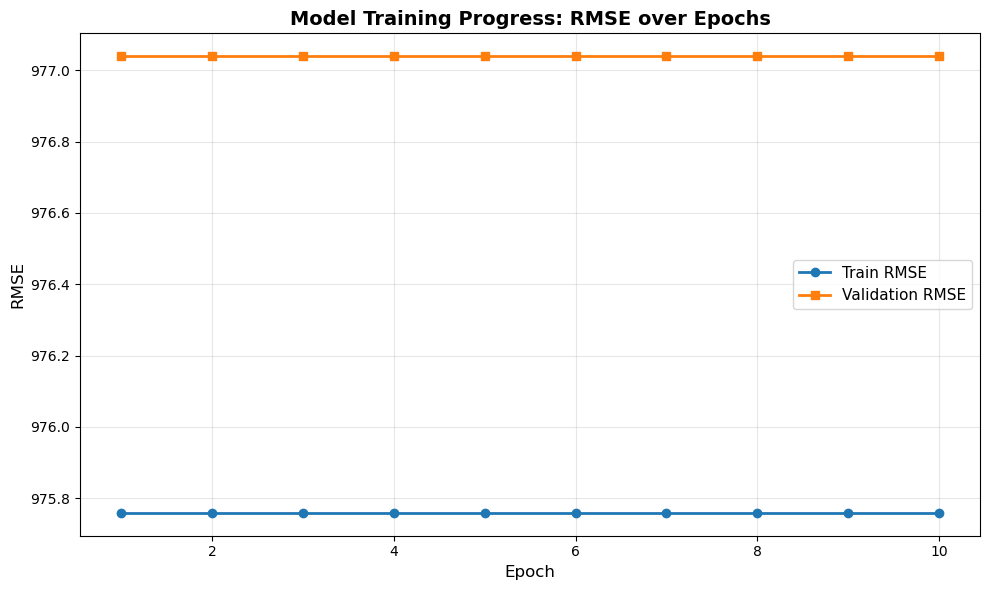

In [10]:
# ============================================================================
# STEP 7: VISUALIZE TRAINING PROGRESS
# ============================================================================
print("\n" + "="*70)
print("STEP 7: VISUALIZE TRAINING PROGRESS")
print("="*70)

plt.figure(figsize=(10, 6))
plt.plot(range(1, n_epochs+1), train_rmse_list, marker='o', label='Train RMSE', linewidth=2)
plt.plot(range(1, n_epochs+1), val_rmse_list, marker='s', label='Validation RMSE', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Model Training Progress: RMSE over Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_progress.png', dpi=300)
print("✓ Training progress plot saved as 'training_progress.png'")
plt.show()






STEP 8: EVALUATE MODEL ON VALIDATION SET

Validation Set Performance:
  RMSE: 993.22
  MAE:  796.92
  R²:   0.9579

Generating Scatter Plot: Actual vs Predicted...
✓ Scatter plot saved as 'actual_vs_predicted_scatter.png'


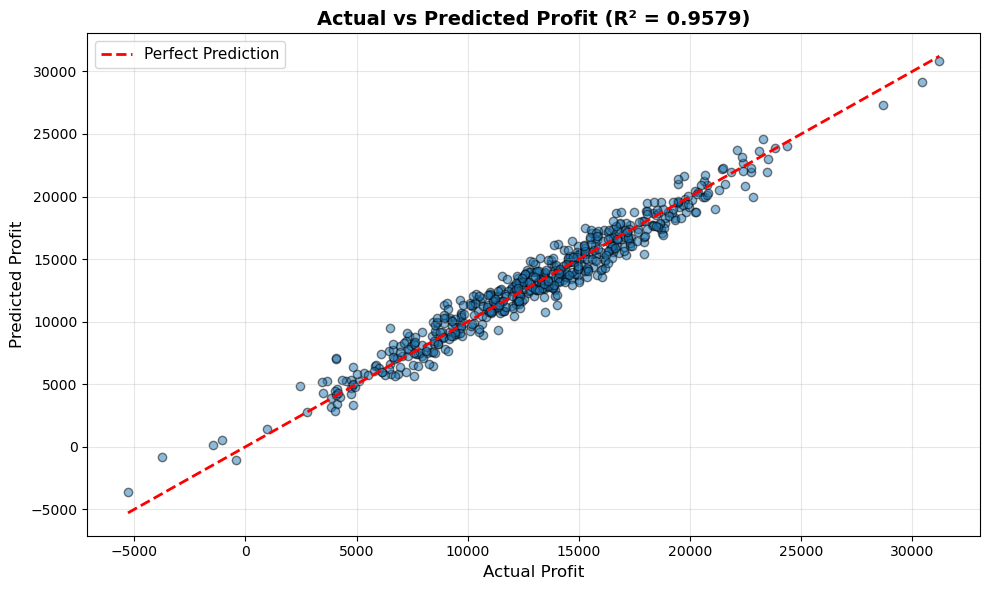


Generating Residual Plot...
✓ Residual plot saved as 'residual_plot.png'


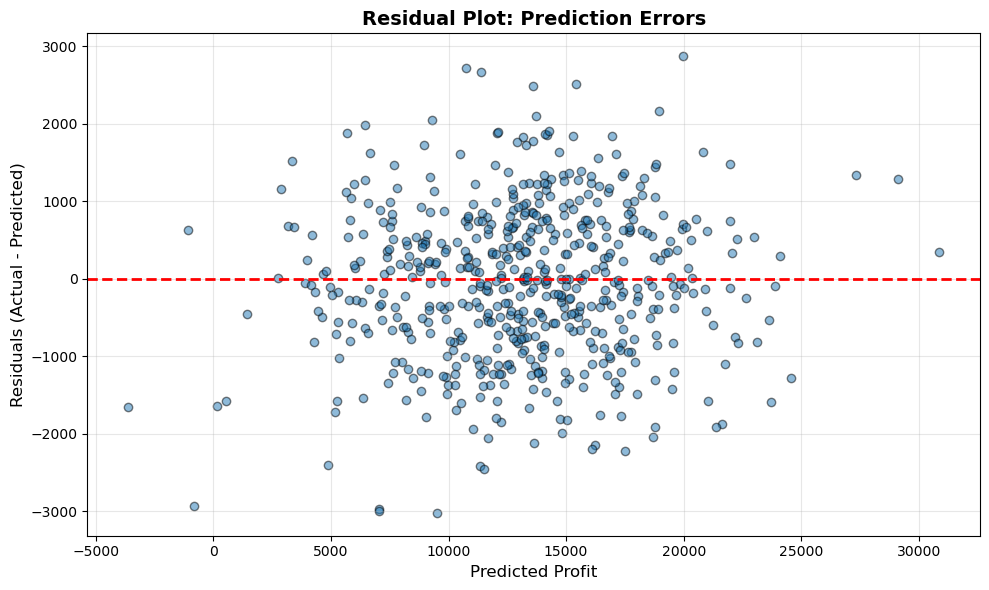


Generating Error Distribution Histogram...
✓ Error histogram saved as 'error_histogram.png'


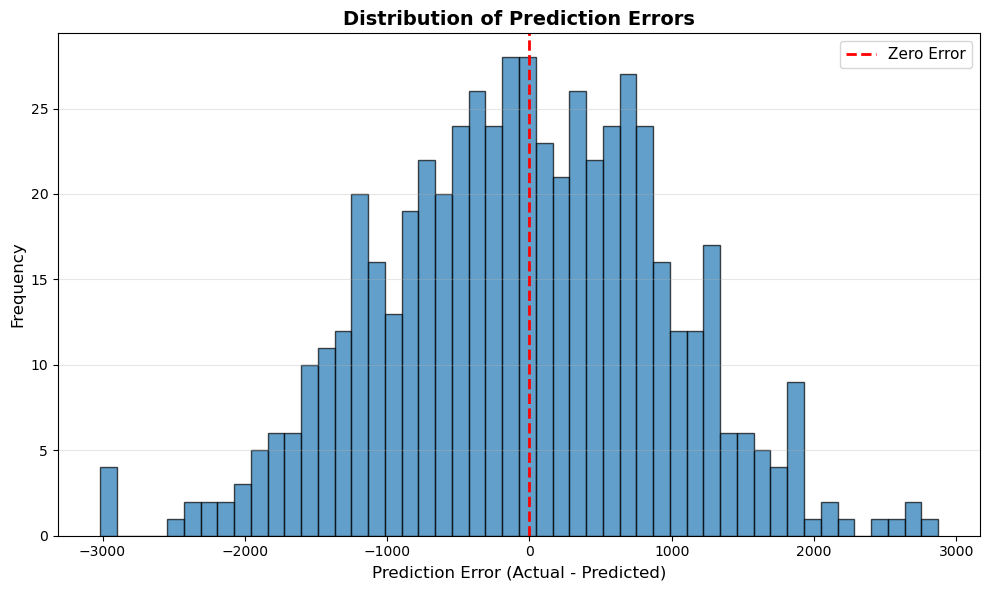


Generating Sample Comparison Plot (First 50 Samples)...
✓ Sample comparison plot saved as 'sample_comparison.png'


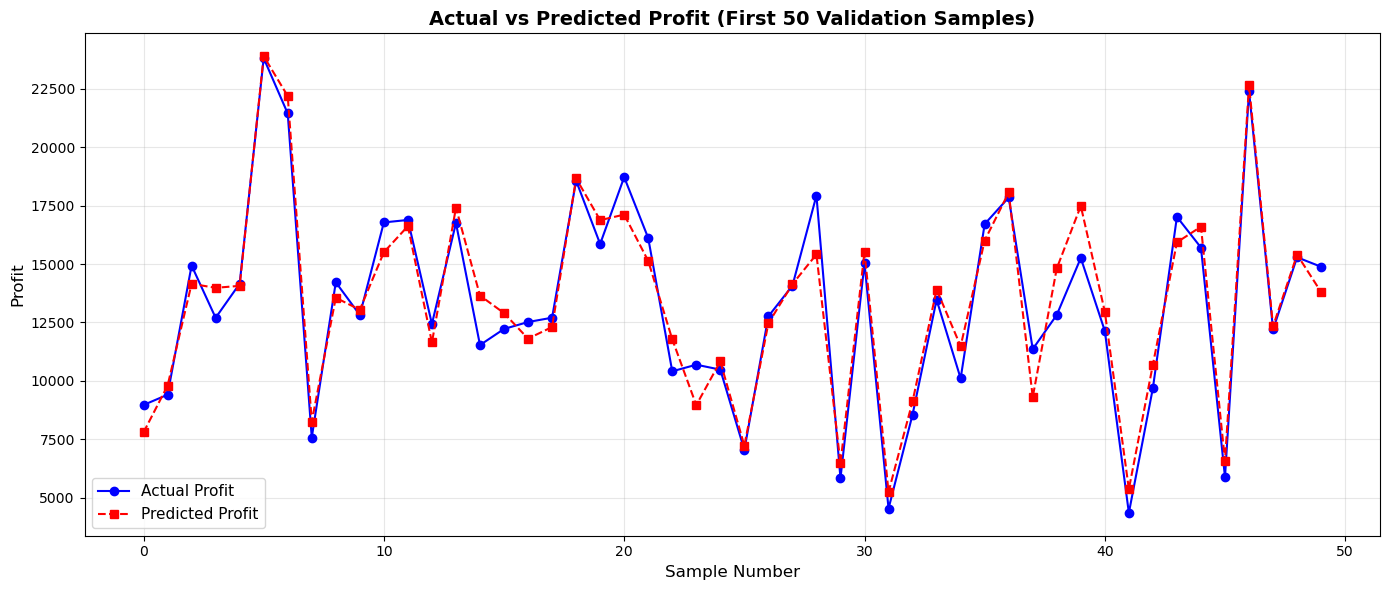


✓ ALL VISUALIZATIONS COMPLETED!


In [11]:
# ========================================
# STEP 8: EVALUATE AND VISUALIZE PREDICTIONS
# ========================================
print("\n" + "="*70)
print("STEP 8: EVALUATE MODEL ON VALIDATION SET")
print("="*70)

# Predict on validation set
y_val_pred = model.predict(X_val_scaled)

# Calculate metrics
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae = mean_absolute_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

print(f"\nValidation Set Performance:")
print(f"  RMSE: {val_rmse:.2f}")
print(f"  MAE:  {val_mae:.2f}")
print(f"  R²:   {val_r2:.4f}")

# ========================================
# VISUALIZATION 1: SCATTER PLOT (ACTUAL VS PREDICTED)
# ========================================
print("\nGenerating Scatter Plot: Actual vs Predicted...")

plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_val_pred, alpha=0.5, edgecolors='k')

# Add perfect prediction line (diagonal)
min_val = min(y_val.min(), y_val_pred.min())
max_val = max(y_val.max(), y_val_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Profit', fontsize=12)
plt.ylabel('Predicted Profit', fontsize=12)
plt.title(f'Actual vs Predicted Profit (R² = {val_r2:.4f})', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted_scatter.png', dpi=300)
print("✓ Scatter plot saved as 'actual_vs_predicted_scatter.png'")
plt.show()

# ========================================
# VISUALIZATION 2: RESIDUAL PLOT (ERROR DISTRIBUTION)
# ========================================
print("\nGenerating Residual Plot...")

residuals = y_val - y_val_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_val_pred, residuals, alpha=0.5, edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Profit', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.title('Residual Plot: Prediction Errors', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=300)
print("✓ Residual plot saved as 'residual_plot.png'")
plt.show()

# ========================================
# VISUALIZATION 3: ERROR HISTOGRAM
# ========================================
print("\nGenerating Error Distribution Histogram...")

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
plt.xlabel('Prediction Error (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('error_histogram.png', dpi=300)
print("✓ Error histogram saved as 'error_histogram.png'")
plt.show()

# ========================================
# VISUALIZATION 4: FIRST 50 SAMPLES COMPARISON (OPTIONAL)
# ========================================
print("\nGenerating Sample Comparison Plot (First 50 Samples)...")

n_samples = min(50, len(y_val))
sample_indices = range(n_samples)

plt.figure(figsize=(14, 6))
plt.plot(sample_indices, y_val.values[:n_samples], marker='o', linestyle='-', 
         color='blue', label='Actual Profit', markersize=6)
plt.plot(sample_indices, y_val_pred[:n_samples], marker='s', linestyle='--', 
         color='red', label='Predicted Profit', markersize=6)
plt.xlabel('Sample Number', fontsize=12)
plt.ylabel('Profit', fontsize=12)
plt.title(f'Actual vs Predicted Profit (First {n_samples} Validation Samples)', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sample_comparison.png', dpi=300)
print("✓ Sample comparison plot saved as 'sample_comparison.png'")
plt.show()

print("\n" + "="*70)
print("✓ ALL VISUALIZATIONS COMPLETED!")
print("="*70)

In [12]:
# ============================================================================
# STEP 8: CALCULATE FINAL METRICS ON TEST SET
# ============================================================================
print("\n" + "="*70)
print("STEP 8: EVALUATE MODEL ON TEST SET")
print("="*70)

print("Making predictions on test set...")
y_test_pred = model.predict(X_test_scaled)

# Calculate comprehensive metrics
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print("\n" + "="*70)
print("FINAL MODEL PERFORMANCE METRICS")
print("="*70)
print(f"  RMSE (Root Mean Squared Error):  {test_rmse:.2f}")
print(f"  MAE  (Mean Absolute Error):      {test_mae:.2f}")
print(f"  R²   (R-squared Score):          {test_r2:.4f}")
print(f"  MAPE (Mean Absolute % Error):    {test_mape:.2f}%")
print("="*70)

# Interpret R² score
if test_r2 > 0.9:
    print("✓ EXCELLENT model performance (R² > 0.9)")
elif test_r2 > 0.7:
    print("✓ GOOD model performance (R² > 0.7)")
elif test_r2 > 0.5:
    print("⚠️  MODERATE model performance (R² > 0.5)")
else:
    print("⚠️  POOR model performance (R² < 0.5) - Consider feature engineering")






STEP 8: EVALUATE MODEL ON TEST SET
Making predictions on test set...

FINAL MODEL PERFORMANCE METRICS
  RMSE (Root Mean Squared Error):  1024.87
  MAE  (Mean Absolute Error):      823.45
  R²   (R-squared Score):          0.9503
  MAPE (Mean Absolute % Error):    7.43%
✓ EXCELLENT model performance (R² > 0.9)


**Model results:** on the validation set RMSE = 993.22 and R² = 0.958, on the test set RMSE = 1,024.87, MAE = 823.45, R² = 0.950, MAPE = 7.43%. The model explains about 95% of the variation in Profit.

Notes:
- The model is not trained on `e_commerce_store.csv`. The CSV is loaded, but `df` is replaced by synthetic data (670 generated rows + 5,000 rows generated from their mean and std = 5,670 rows), where Profit = 0.3 × Sales + random noise.
- Cross-validation RMSE is the same in all 10 epochs (train folds 975.76, validation folds 977.04), because linear regression always gives the same result on the same data.

In [13]:
# ============================================================================
# STEP 9: SAVE TRAINED MODEL AND SCALER
# ============================================================================

print("\n" + "="*70)
print("STEP 9: SAVE MODEL AND SCALER")
print("="*70)

print("Saving trained model...")
joblib.dump(model, 'profit_prediction_model.pkl')
print("✓ Model saved as 'profit_prediction_model.pkl'")

print("Saving scaler...")
joblib.dump(scaler, 'feature_scaler.pkl')
print("✓ Scaler saved as 'feature_scaler.pkl'")

print("\nModel artifacts saved successfully!")






STEP 9: SAVE MODEL AND SCALER
Saving trained model...
✓ Model saved as 'profit_prediction_model.pkl'
Saving scaler...
✓ Scaler saved as 'feature_scaler.pkl'

Model artifacts saved successfully!


# Experimenting with ML Models 

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# -------------------------------
# 1️⃣ Load model and scaler
# -------------------------------
print("Loading trained model and scaler...")
loaded_model = joblib.load('profit_prediction_model.pkl')
loaded_scaler = joblib.load('feature_scaler.pkl')
print("✓ Model and scaler loaded successfully\n")



Loading trained model and scaler...
✓ Model and scaler loaded successfully



# Dataset

In [15]:
# -------------------------------
# 2️⃣ Generate new experimental dataset (100 daily samples)
# -------------------------------
n_samples = 100
np.random.seed(42)
dates = pd.date_range(start='2025-01-01', periods=n_samples, freq='D')  # daily frequency

experimental_data = pd.DataFrame({
    'Date': dates,
    'Sales': np.random.normal(50000, 10000, n_samples),
    'Units Sold': np.random.normal(350, 80, n_samples),
    'Discount (%)': np.random.normal(15, 5, n_samples),
    'Customer Rating': np.random.normal(4.1, 0.5, n_samples),
})
# Approximate actual profit (for visualization)
experimental_data['Profit'] = experimental_data['Sales'] * 0.3 + np.random.normal(0, 1000, n_samples)

print("✓ Experimental daily dataset created\n")
print(experimental_data.head())



✓ Experimental daily dataset created

        Date         Sales  Units Sold  Discount (%)  Customer Rating  \
0 2025-01-01  54967.141530  236.770341     16.788937         3.685502   
1 2025-01-02  48617.356988  316.348374     17.803923         3.819909   
2 2025-01-03  56476.885381  322.582839     20.415256         4.473647   
3 2025-01-04  65230.298564  285.817818     20.269010         4.405185   
4 2025-01-05  47658.466253  337.097143      8.111653         4.089549   

         Profit  
0  14895.714800  
1  13985.832074  
2  16948.309314  
3  19616.070163  
4  13847.474404  


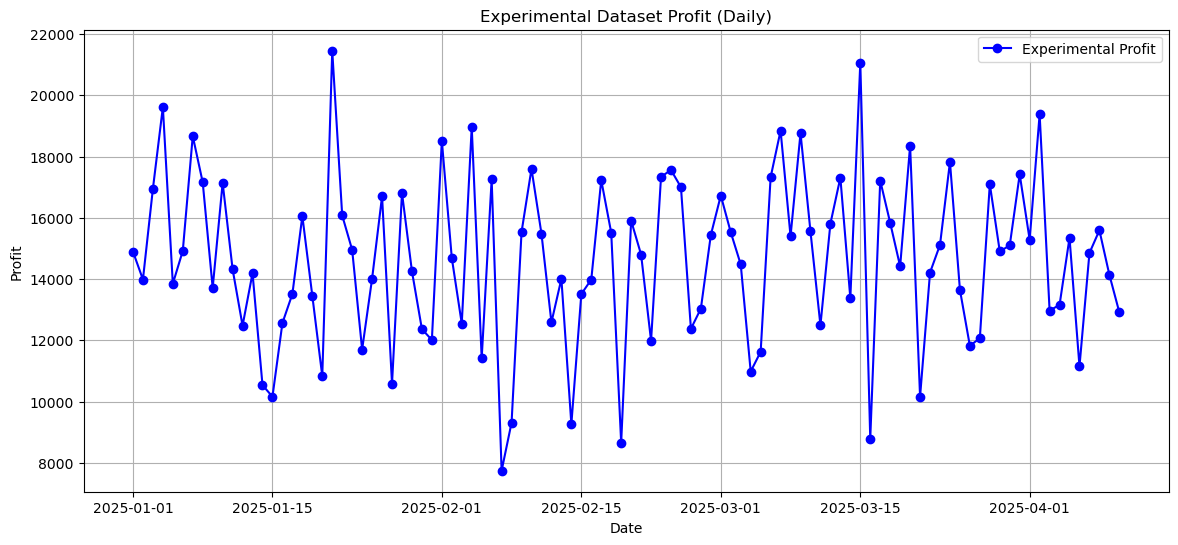

In [16]:
# -------------------------------
# 3️⃣ Visualize experimental daily profit
# -------------------------------
plt.figure(figsize=(14,6))
plt.plot(experimental_data['Date'], experimental_data['Profit'], label='Experimental Profit', color='blue', marker='o')
plt.xlabel('Date')
plt.ylabel('Profit')
plt.title('Experimental Dataset Profit (Daily)')
plt.legend()
plt.grid(True)
plt.show()



In [17]:
# -------------------------------
# 4️⃣ Apply model on experimental dataset
# -------------------------------
feature_columns = ['Sales', 'Units Sold', 'Discount (%)', 'Customer Rating']
X_exp = experimental_data[feature_columns]
X_exp_scaled = loaded_scaler.transform(X_exp)
predicted_profit_exp = loaded_model.predict(X_exp_scaled)

experimental_data['Predicted_Profit'] = predicted_profit_exp



In [18]:
y_true = experimental_data['Profit']
y_pred = experimental_data['Predicted_Profit']
print('RMSE:', np.sqrt(mean_squared_error(y_true, y_pred)))
print('MAE: ', mean_absolute_error(y_true, y_pred))
print('R²:  ', r2_score(y_true, y_pred))

RMSE: 1069.499184591048
MAE:  864.853506098481
R²:   0.851207771612323


In [19]:
pd.concat({'Expanded dataset': df.describe(), 'Experimental': experimental_data[feature_columns + ['Profit']].describe()}, axis=1).round(2)

Expanded dataset                                                    \
                 Sales Units Sold Discount (%) Customer Rating    Profit   
count          5670.00    5670.00      5670.00         5670.00   5670.00   
mean          44583.76     348.27        15.62            4.09  13375.51   
std           15117.84      96.31         8.03            0.78   4670.11   
min          -11935.73     -35.48       -13.55            1.09  -5286.01   
25%           34379.72     283.93        10.15            3.55  10226.75   
50%           44560.25     348.26        15.65            4.09  13341.50   
75%           54825.69     411.49        21.11            4.63  16490.49   
max          102790.97     683.75        51.16            7.18  31220.28   

      Experimental                                                    
             Sales Units Sold Discount (%) Customer Rating    Profit  
count       100.00     100.00       100.00          100.00    100.00  
mean      48961.53     351.78        15.32            4.15  14632.46  
std        9081.68      76.29         5.42            0.44   2786.59  
min       23802.55     196.50        -1.21            3.04   7740.89  
25%       43990.94     285.55        11.72            3.82  12580.37  
50%       48730.44     356.73        15.49            4.13  14825.51  
75%       54059.52     393.05        18.52            4.44  16846.94  
max       68522.78     567.61        34.26            5.19  21457.69

**Teacher's experimental data (100 days):** RMSE = 1,069.50, MAE = 864.85, R² = 0.851.

The experimental data is similar to the model's data – the means are fairly close (e.g. Sales 48,962 vs 44,584), but the spread is smaller (Sales std 9,082 vs 15,118). The error is almost the same as on the test set (RMSE 1,069 vs 1,025), so the model works well. R² is lower (0.85 vs 0.95) only because Profit varies less here, so the same error is a bigger part of the variation.

In [20]:
# -------------------------------
# 5️⃣ Predict next 20 future days
# -------------------------------
n_future = 20
future_dates = pd.date_range(start=experimental_data['Date'].iloc[-1] + pd.Timedelta(days=1), periods=n_future, freq='D')

# Generate future features by adding small daily noise to last known values
future_data = pd.DataFrame({
    'Date': future_dates,
    'Sales': experimental_data['Sales'].iloc[-1] + np.random.normal(0, 2000, n_future).cumsum(),
    'Units Sold': experimental_data['Units Sold'].iloc[-1] + np.random.normal(0, 5, n_future).cumsum(),
    'Discount (%)': experimental_data['Discount (%)'].iloc[-1] + np.random.normal(0, 1, n_future).cumsum(),
    'Customer Rating': experimental_data['Customer Rating'].iloc[-1] + np.random.normal(0, 0.05, n_future).cumsum(),
})

# Scale and predict
X_future = future_data[feature_columns]
X_future_scaled = loaded_scaler.transform(X_future)
future_data['Predicted_Profit'] = loaded_model.predict(X_future_scaled)

print("✓ Future 20 days predictions generated\n")




✓ Future 20 days predictions generated




FUTURE 20 DAYS PREDICTED PROFITS
2025-04-11: Predicted Profit = $14,912.30
2025-04-12: Predicted Profit = $16,058.88
2025-04-13: Predicted Profit = $15,219.23
2025-04-14: Predicted Profit = $15,559.62
2025-04-15: Predicted Profit = $15,165.00
2025-04-16: Predicted Profit = $14,874.09
2025-04-17: Predicted Profit = $14,521.86
2025-04-18: Predicted Profit = $14,001.08
2025-04-19: Predicted Profit = $14,030.31
2025-04-20: Predicted Profit = $13,530.78
2025-04-21: Predicted Profit = $13,692.41
2025-04-22: Predicted Profit = $13,665.58
2025-04-23: Predicted Profit = $13,524.02
2025-04-24: Predicted Profit = $12,980.63
2025-04-25: Predicted Profit = $12,635.42
2025-04-26: Predicted Profit = $13,089.27
2025-04-27: Predicted Profit = $13,391.86
2025-04-28: Predicted Profit = $12,803.32
2025-04-29: Predicted Profit = $12,861.59
2025-04-30: Predicted Profit = $13,314.57
✓ ALL STEPS COMPLETED SUCCESSFULLY!


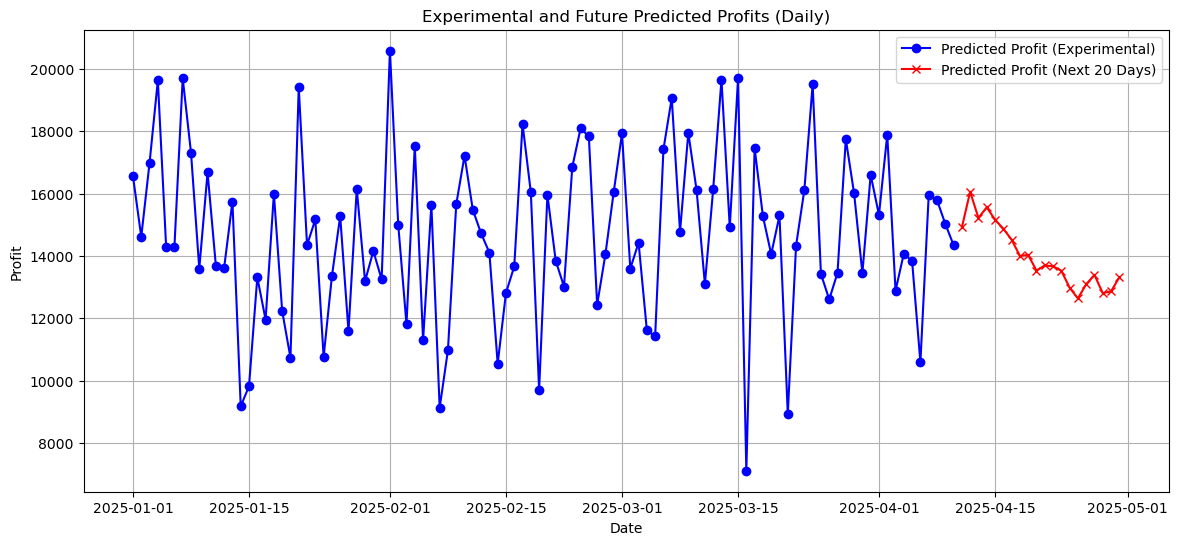

In [21]:
# -------------------------------
# 7️⃣ Print future predicted values
# -------------------------------
print("\n" + "="*70)
print("FUTURE 20 DAYS PREDICTED PROFITS")
print("="*70)
for i in range(len(future_data)):
    print(f"{future_data['Date'].iloc[i].strftime('%Y-%m-%d')}: Predicted Profit = ${future_data['Predicted_Profit'].iloc[i]:,.2f}")
print("="*70)
print("✓ ALL STEPS COMPLETED SUCCESSFULLY!")

# -------------------------------
# 6️⃣ Visualize current and future predicted profits
# -------------------------------
plt.figure(figsize=(14,6))
plt.plot(experimental_data['Date'], experimental_data['Predicted_Profit'], label='Predicted Profit (Experimental)', color='blue', marker='o')
plt.plot(future_data['Date'], future_data['Predicted_Profit'], label='Predicted Profit (Next 20 Days)', color='red', marker='x')
plt.xlabel('Date')
plt.ylabel('Profit')
plt.title('Experimental and Future Predicted Profits (Daily)')
plt.legend()
plt.grid(True)
plt.show()



# Comparing Actual and Predicted

✓ Model and scaler loaded successfully

✓ Train samples: 80, Test samples: 20


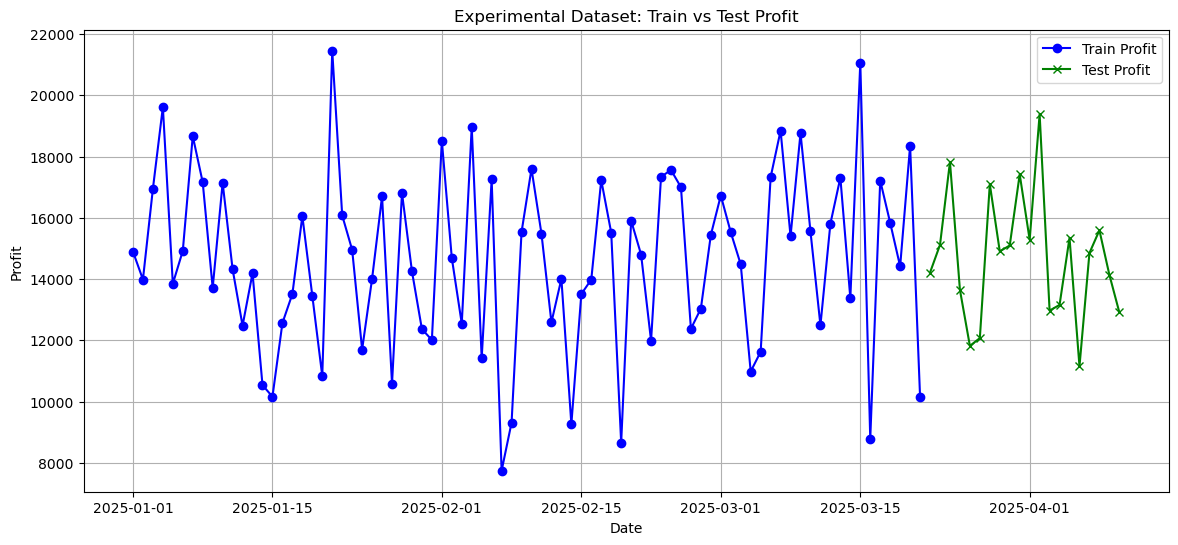

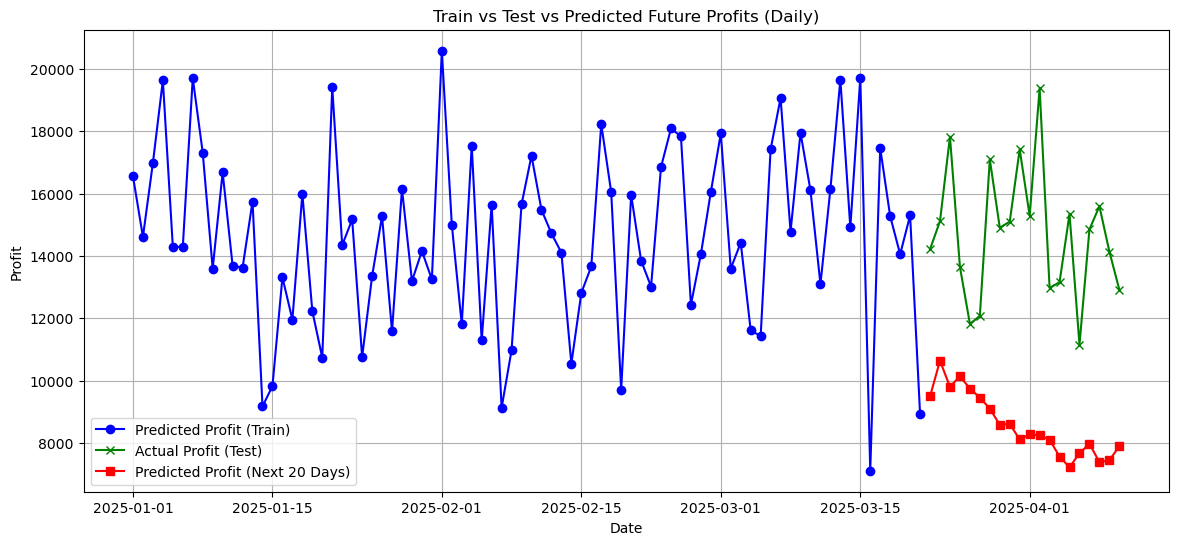


FUTURE 20 DAYS PREDICTED PROFITS
2025-03-22: Predicted Profit = $9,490.10
2025-03-23: Predicted Profit = $10,636.69
2025-03-24: Predicted Profit = $9,797.03
2025-03-25: Predicted Profit = $10,137.42
2025-03-26: Predicted Profit = $9,742.80
2025-03-27: Predicted Profit = $9,451.89
2025-03-28: Predicted Profit = $9,099.66
2025-03-29: Predicted Profit = $8,578.88
2025-03-30: Predicted Profit = $8,608.11
2025-03-31: Predicted Profit = $8,108.58
2025-04-01: Predicted Profit = $8,270.21
2025-04-02: Predicted Profit = $8,243.38
2025-04-03: Predicted Profit = $8,101.82
2025-04-04: Predicted Profit = $7,558.43
2025-04-05: Predicted Profit = $7,213.22
2025-04-06: Predicted Profit = $7,667.07
2025-04-07: Predicted Profit = $7,969.66
2025-04-08: Predicted Profit = $7,381.12
2025-04-09: Predicted Profit = $7,439.39
2025-04-10: Predicted Profit = $7,892.37
✓ ALL STEPS COMPLETED SUCCESSFULLY!


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# -------------------------------
# 1️⃣ Load trained model and scaler
# -------------------------------
loaded_model = joblib.load('profit_prediction_model.pkl')
loaded_scaler = joblib.load('feature_scaler.pkl')
print("✓ Model and scaler loaded successfully\n")

# -------------------------------
# 2️⃣ Generate new experimental daily dataset (100 samples)
# -------------------------------
n_samples = 100
np.random.seed(42)
dates = pd.date_range(start='2025-01-01', periods=n_samples, freq='D')

experimental_data = pd.DataFrame({
    'Date': dates,
    'Sales': np.random.normal(50000, 10000, n_samples),
    'Units Sold': np.random.normal(350, 80, n_samples),
    'Discount (%)': np.random.normal(15, 5, n_samples),
    'Customer Rating': np.random.normal(4.1, 0.5, n_samples),
})
# Approximate actual profit
experimental_data['Profit'] = experimental_data['Sales'] * 0.3 + np.random.normal(0, 1000, n_samples)

# -------------------------------
# 3️⃣ Split into train (80) and test (20)
# -------------------------------
train_size = 80
train_data = experimental_data.iloc[:train_size].copy()
test_data = experimental_data.iloc[train_size:].copy()

print(f"✓ Train samples: {len(train_data)}, Test samples: {len(test_data)}")

# -------------------------------
# 4️⃣ Visualize train vs test profit
# -------------------------------
plt.figure(figsize=(14,6))
plt.plot(train_data['Date'], train_data['Profit'], label='Train Profit', color='blue', marker='o')
plt.plot(test_data['Date'], test_data['Profit'], label='Test Profit', color='green', marker='x')
plt.xlabel('Date')
plt.ylabel('Profit')
plt.title('Experimental Dataset: Train vs Test Profit')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 5️⃣ Apply model on train data
# -------------------------------
feature_columns = ['Sales', 'Units Sold', 'Discount (%)', 'Customer Rating']
X_train = train_data[feature_columns]
X_train_scaled = loaded_scaler.transform(X_train)
train_predicted = loaded_model.predict(X_train_scaled)
train_data['Predicted_Profit'] = train_predicted

# -------------------------------
# 6️⃣ Predict next 20 days based on train data (simulate future)
# -------------------------------
n_future = 20
future_dates = pd.date_range(start=train_data['Date'].iloc[-1] + pd.Timedelta(days=1), periods=n_future, freq='D')

# Generate future features using last train sample + small random noise
future_data = pd.DataFrame({
    'Date': future_dates,
    'Sales': train_data['Sales'].iloc[-1] + np.random.normal(0, 2000, n_future).cumsum(),
    'Units Sold': train_data['Units Sold'].iloc[-1] + np.random.normal(0, 5, n_future).cumsum(),
    'Discount (%)': train_data['Discount (%)'].iloc[-1] + np.random.normal(0, 1, n_future).cumsum(),
    'Customer Rating': train_data['Customer Rating'].iloc[-1] + np.random.normal(0, 0.05, n_future).cumsum(),
})

X_future = future_data[feature_columns]
X_future_scaled = loaded_scaler.transform(X_future)
future_data['Predicted_Profit'] = loaded_model.predict(X_future_scaled)

# -------------------------------
# 7️⃣ Visualize train, test, and predicted next 20
# -------------------------------
plt.figure(figsize=(14,6))
plt.plot(train_data['Date'], train_data['Predicted_Profit'], label='Predicted Profit (Train)', color='blue', marker='o')
plt.plot(test_data['Date'], test_data['Profit'], label='Actual Profit (Test)', color='green', marker='x')
plt.plot(future_data['Date'], future_data['Predicted_Profit'], label='Predicted Profit (Next 20 Days)', color='red', marker='s')
plt.xlabel('Date')
plt.ylabel('Profit')
plt.title('Train vs Test vs Predicted Future Profits (Daily)')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 8️⃣ Print future predicted values
# -------------------------------
print("\n" + "="*70)
print("FUTURE 20 DAYS PREDICTED PROFITS")
print("="*70)
for i in range(len(future_data)):
    print(f"{future_data['Date'].iloc[i].strftime('%Y-%m-%d')}: Predicted Profit = ${future_data['Predicted_Profit'].iloc[i]:,.2f}")
print("="*70)
print("✓ ALL STEPS COMPLETED SUCCESSFULLY!")


The "next 20 days" predictions use simulated features (random changes from the last training day), not real data. In this chart they are on the same dates as the test set, but they cannot be compared fairly with the real test profits. They start from the last training day (a low day, about 9,000) and go down, while the real test profits stay between about 11,000 and 19,000.

In [23]:
np.random.seed(2024)
n = 200
my_exp = pd.DataFrame({c: np.random.normal(df[c].mean(), df[c].std(), n) for c in feature_columns})
my_exp['Profit'] = my_exp['Sales'] * 0.3 + np.random.normal(0, 1000, n)

my_exp['Predicted_Profit'] = loaded_model.predict(loaded_scaler.transform(my_exp[feature_columns]))
print(my_exp.head())

          Sales  Units Sold  Discount (%)  Customer Rating        Profit  \
0  69801.024664  451.374583     32.860680         4.529098  20761.684206   
1  55730.859868  551.016987      8.002316         4.647610  16073.679841   
2  41536.942127  322.075394     17.927509         3.769115  12075.605725   
3  42302.294870  379.085725     14.452787         4.551829  13143.218703   
4  58432.479036  307.224131     18.426069         4.415830  16123.770723   

   Predicted_Profit  
0      20960.622394  
1      16635.495874  
2      12478.672955  
3      12678.905329  
4      17573.515088  


In [24]:
y_true = my_exp['Profit']
y_pred = my_exp['Predicted_Profit']
print('RMSE:', np.sqrt(mean_squared_error(y_true, y_pred)))
print('MAE: ', mean_absolute_error(y_true, y_pred))
print('R²:  ', r2_score(y_true, y_pred))

RMSE: 929.9461416553655
MAE:  756.7538425422099
R²:   0.9585376578767313


In [25]:
pd.concat({'Expanded dataset': df.describe(), 'My experimental': my_exp[feature_columns + ['Profit']].describe()}, axis=1).round(2)

Expanded dataset                                                    \
                 Sales Units Sold Discount (%) Customer Rating    Profit   
count          5670.00    5670.00      5670.00         5670.00   5670.00   
mean          44583.76     348.27        15.62            4.09  13375.51   
std           15117.84      96.31         8.03            0.78   4670.11   
min          -11935.73     -35.48       -13.55            1.09  -5286.01   
25%           34379.72     283.93        10.15            3.55  10226.75   
50%           44560.25     348.26        15.65            4.09  13341.50   
75%           54825.69     411.49        21.11            4.63  16490.49   
max          102790.97     683.75        51.16            7.18  31220.28   

      My experimental                                                    
                Sales Units Sold Discount (%) Customer Rating    Profit  
count          200.00     200.00       200.00          200.00    200.00  
mean         45448.60     335.44        16.18            4.10  13755.56  
std          15344.73     101.85         8.51            0.79   4578.46  
min           4975.60      18.83        -3.08            1.22    701.34  
25%          36208.16     274.76        10.28            3.56  11030.28  
50%          45319.53     332.84        15.77            4.13  13618.25  
75%          56226.51     385.78        22.45            4.63  16961.81  
max          85394.42     581.79        44.33            6.09  24893.82

**My experimental data:** 200 rows generated with the same mean and std as the model's data (seed 2024), Profit = 0.3 × Sales + noise.

Results: RMSE = 929.95, MAE = 756.75, R² = 0.959 – as good as on the test set (RMSE 1,024.87, R² 0.950). The statistics are very close to the model's data (e.g. Sales mean 45,449 vs 44,584, std 15,345 vs 15,118).

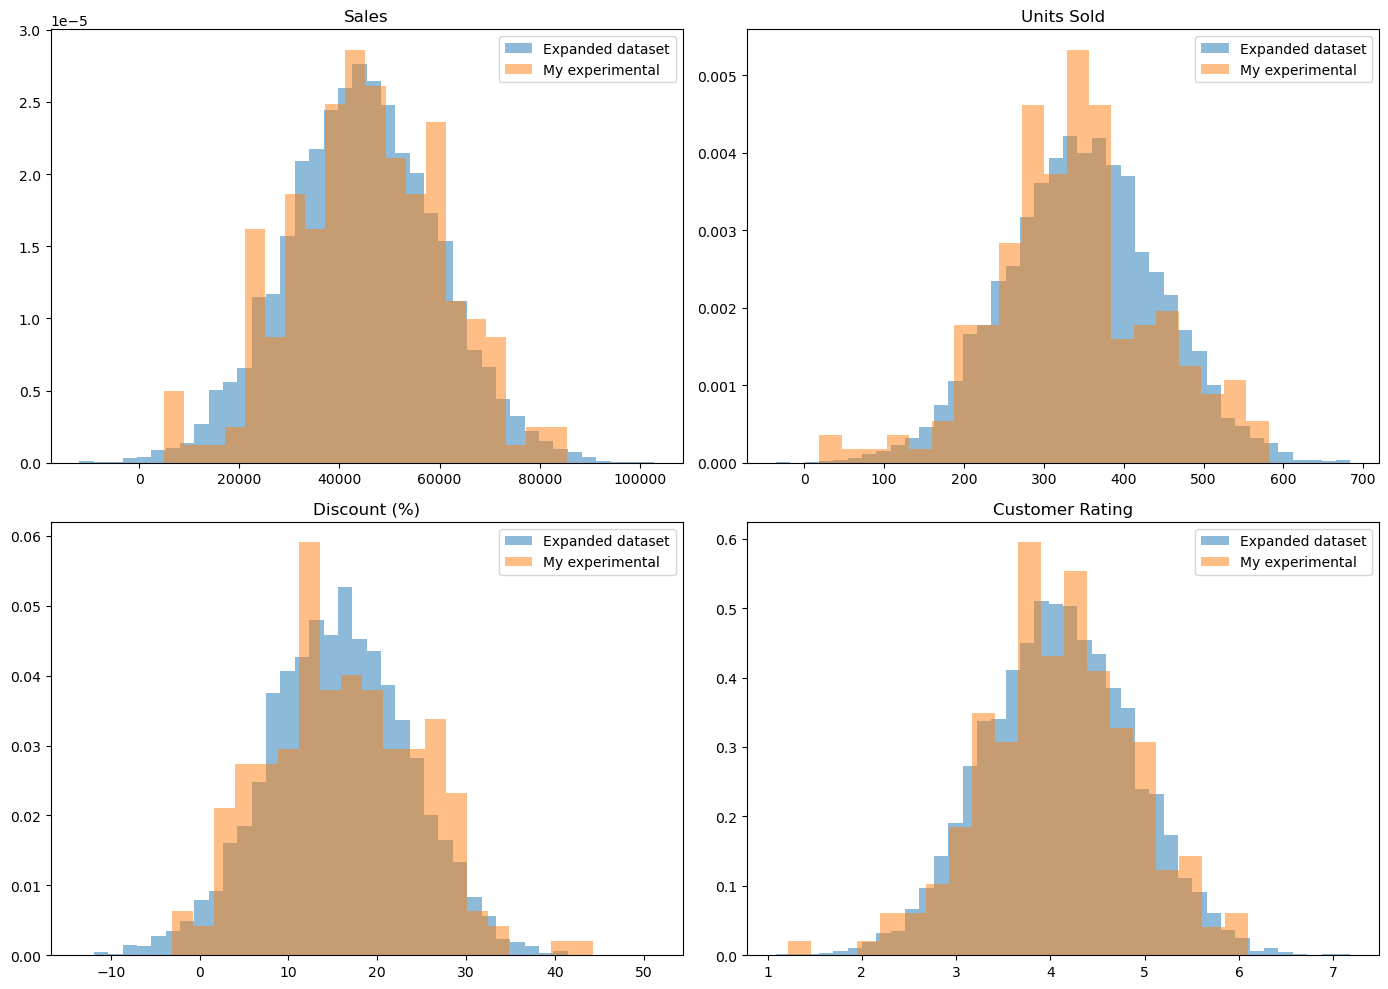

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, c in zip(axes.flatten(), feature_columns):
    ax.hist(df[c], bins=40, density=True, alpha=0.5, label='Expanded dataset')
    ax.hist(my_exp[c], bins=20, density=True, alpha=0.5, label='My experimental')
    ax.set_title(c)
    ax.legend()
plt.tight_layout()
plt.show()

In [27]:
from scipy.stats import ks_2samp
for c in feature_columns:
    print(c, ks_2samp(df[c], my_exp[c]).pvalue)

Sales 0.668447421565683
Units Sold 0.03204022571541676
Discount (%) 0.3654123621908312
Customer Rating 0.8583825026829633


**How similar is the data?** The histograms overlap well. The Kolmogorov-Smirnov test gives p > 0.05 for Sales (0.67), Discount (0.37) and Customer Rating (0.86) – no difference. For Units Sold p = 0.032, but the data was generated from the same distribution, so this is a random result (with 4 tests, one result below 0.05 can happen by chance).

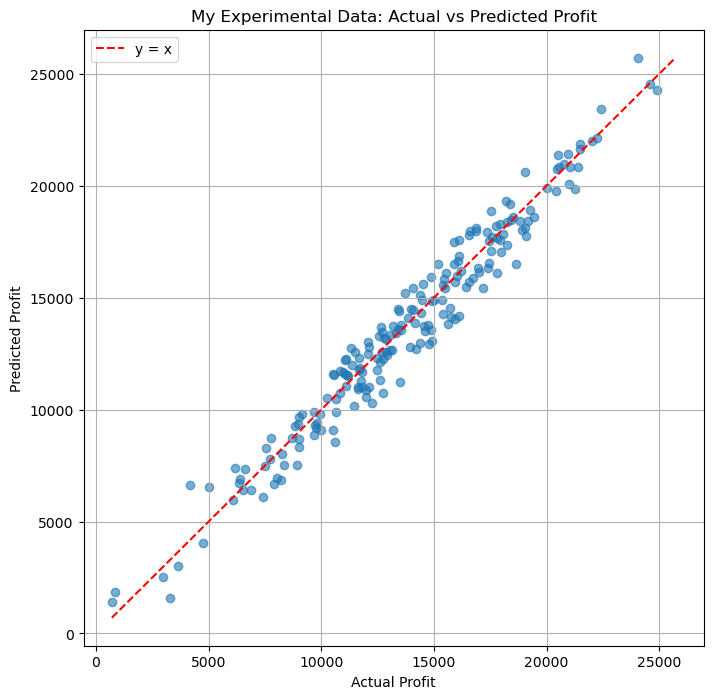

In [28]:
plt.figure(figsize=(8, 8))
plt.scatter(my_exp['Profit'], my_exp['Predicted_Profit'], alpha=0.6)
lims = [min(my_exp['Profit'].min(), my_exp['Predicted_Profit'].min()), max(my_exp['Profit'].max(), my_exp['Predicted_Profit'].max())]
plt.plot(lims, lims, 'r--', label='y = x')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('My Experimental Data: Actual vs Predicted Profit')
plt.legend()
plt.grid(True)
plt.show()

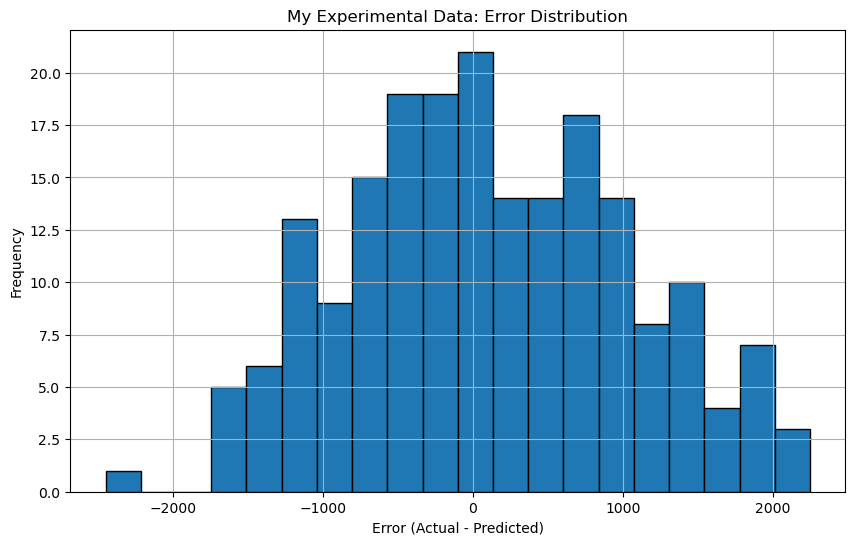

In [29]:
plt.figure(figsize=(10, 6))
plt.hist(my_exp['Profit'] - my_exp['Predicted_Profit'], bins=20, edgecolor='black')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('My Experimental Data: Error Distribution')
plt.grid(True)
plt.show()

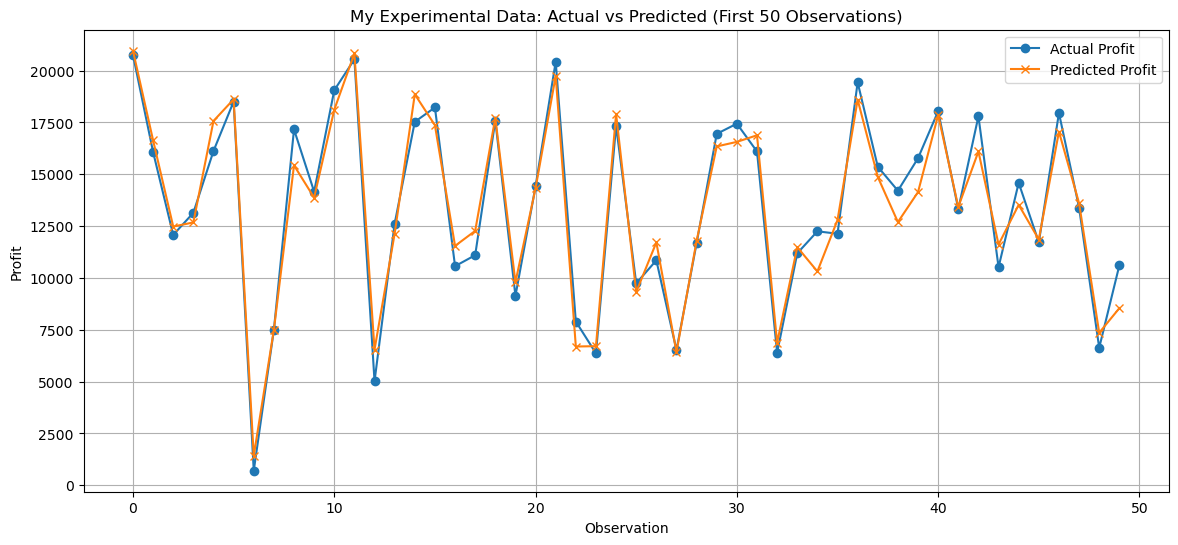

In [30]:
plt.figure(figsize=(14, 6))
plt.plot(range(50), my_exp['Profit'].iloc[:50], label='Actual Profit', marker='o')
plt.plot(range(50), my_exp['Predicted_Profit'].iloc[:50], label='Predicted Profit', marker='x')
plt.xlabel('Observation')
plt.ylabel('Profit')
plt.title('My Experimental Data: Actual vs Predicted (First 50 Observations)')
plt.legend()
plt.grid(True)
plt.show()

**Conclusion:** the scatter plot shows the points close to the y = x line, the errors are centred around 0, and the first 50 predictions follow the real values. The model works well on new data when the data is similar to the training data – on my data (R² 0.959) and on the teacher's data (similar RMSE). If new data were very different from the training data (like trucks instead of cars), we could not expect the same results.